# Experiment 0 — Frequency-Only Baseline (DeepDetect)
**Purpose:** Verify that the frequency branch alone can capture a useful signal on DeepDetect at 224×224 before interpreting fusion experiment results.

This is the DeepDetect equivalent of the CIFAKE frequency-only baseline.
Unlike CIFAKE where the whole 32×32 image was used as the patch, here a genuine 56×56 flat patch is extracted from the 224×224 image.

**Threshold:** >= 70% — proceed. 60-70% — weak but not blocked. < 60% — stop, frequency representation is not capturing useful signal on this dataset.


## 1. Environment

In [8]:
import sys, os
import numpy as np
sys.path.insert(0, os.path.abspath(".."))

import torch
print(f"Python:  {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {'cuda' if torch.cuda.is_available() else 'cpu'}")
if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
    print(f"Memory:  {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Python:  3.12.3
PyTorch: 2.11.0+cu128
Device:  cuda
GPU:     NVIDIA RTX PRO 4000 Blackwell
Memory:  25.2 GB


## 2. Configuration

Unlike CIFAKE:
- image_size = 224 (full resolution)
- patch_size = 56 (genuine sub-patch extraction, not whole image)
- More epochs needed — frequency patterns in face images are subtler
- All augmentations on for DeepDetect


In [2]:
from config import Config

cfg = Config()

# ── CHANGE THIS if your path differs ─────────────────────────────
cfg.data.deepdetect_root = "../data/raw/deep_detect/data"
# ─────────────────────────────────────────────────────────────────

cfg.data.dataset          = "deepdetect"
cfg.data.image_size       = 224
cfg.data.batch_size       = 64
cfg.data.num_workers      = 4
cfg.backbone.img_size     = 224
cfg.frequency.patch_size  = 56

# Augmentations — all on for DeepDetect
cfg.data.jpeg_aug          = True
cfg.data.blur_aug          = True
cfg.data.noise_aug         = True
cfg.data.recompression_aug = True
cfg.data.mixed_aug         = True
cfg.data.mixed_aug_prob    = 0.3

cfg.train.epochs       = 30
cfg.experiment_name    = "dd_freq_only_baseline"
cfg.notes              = "DeepDetect freq-only baseline, 56x56 patch, 224x224"

print("Config ready.")
print(f"  DeepDetect root: {cfg.data.deepdetect_root}")
print(f"  Image size:      {cfg.data.image_size}x{cfg.data.image_size}")
print(f"  Patch size:      {cfg.frequency.patch_size}x{cfg.frequency.patch_size}")
print(f"  Epochs:          {cfg.train.epochs}")


Config ready.
  DeepDetect root: ../data/raw/deep_detect/data
  Image size:      224x224
  Patch size:      56x56
  Epochs:          30


## 3. Load Data

In [3]:
from data.deepdetect import get_deepdetect_loaders

train_loader, val_loader, test_loader = get_deepdetect_loaders(cfg)


Train: 76,848  Val: 13,561  Test: 21,776


## 4. FFT Spectrum Visualisation
Verify the FFT looks sensible on DeepDetect face images before training.

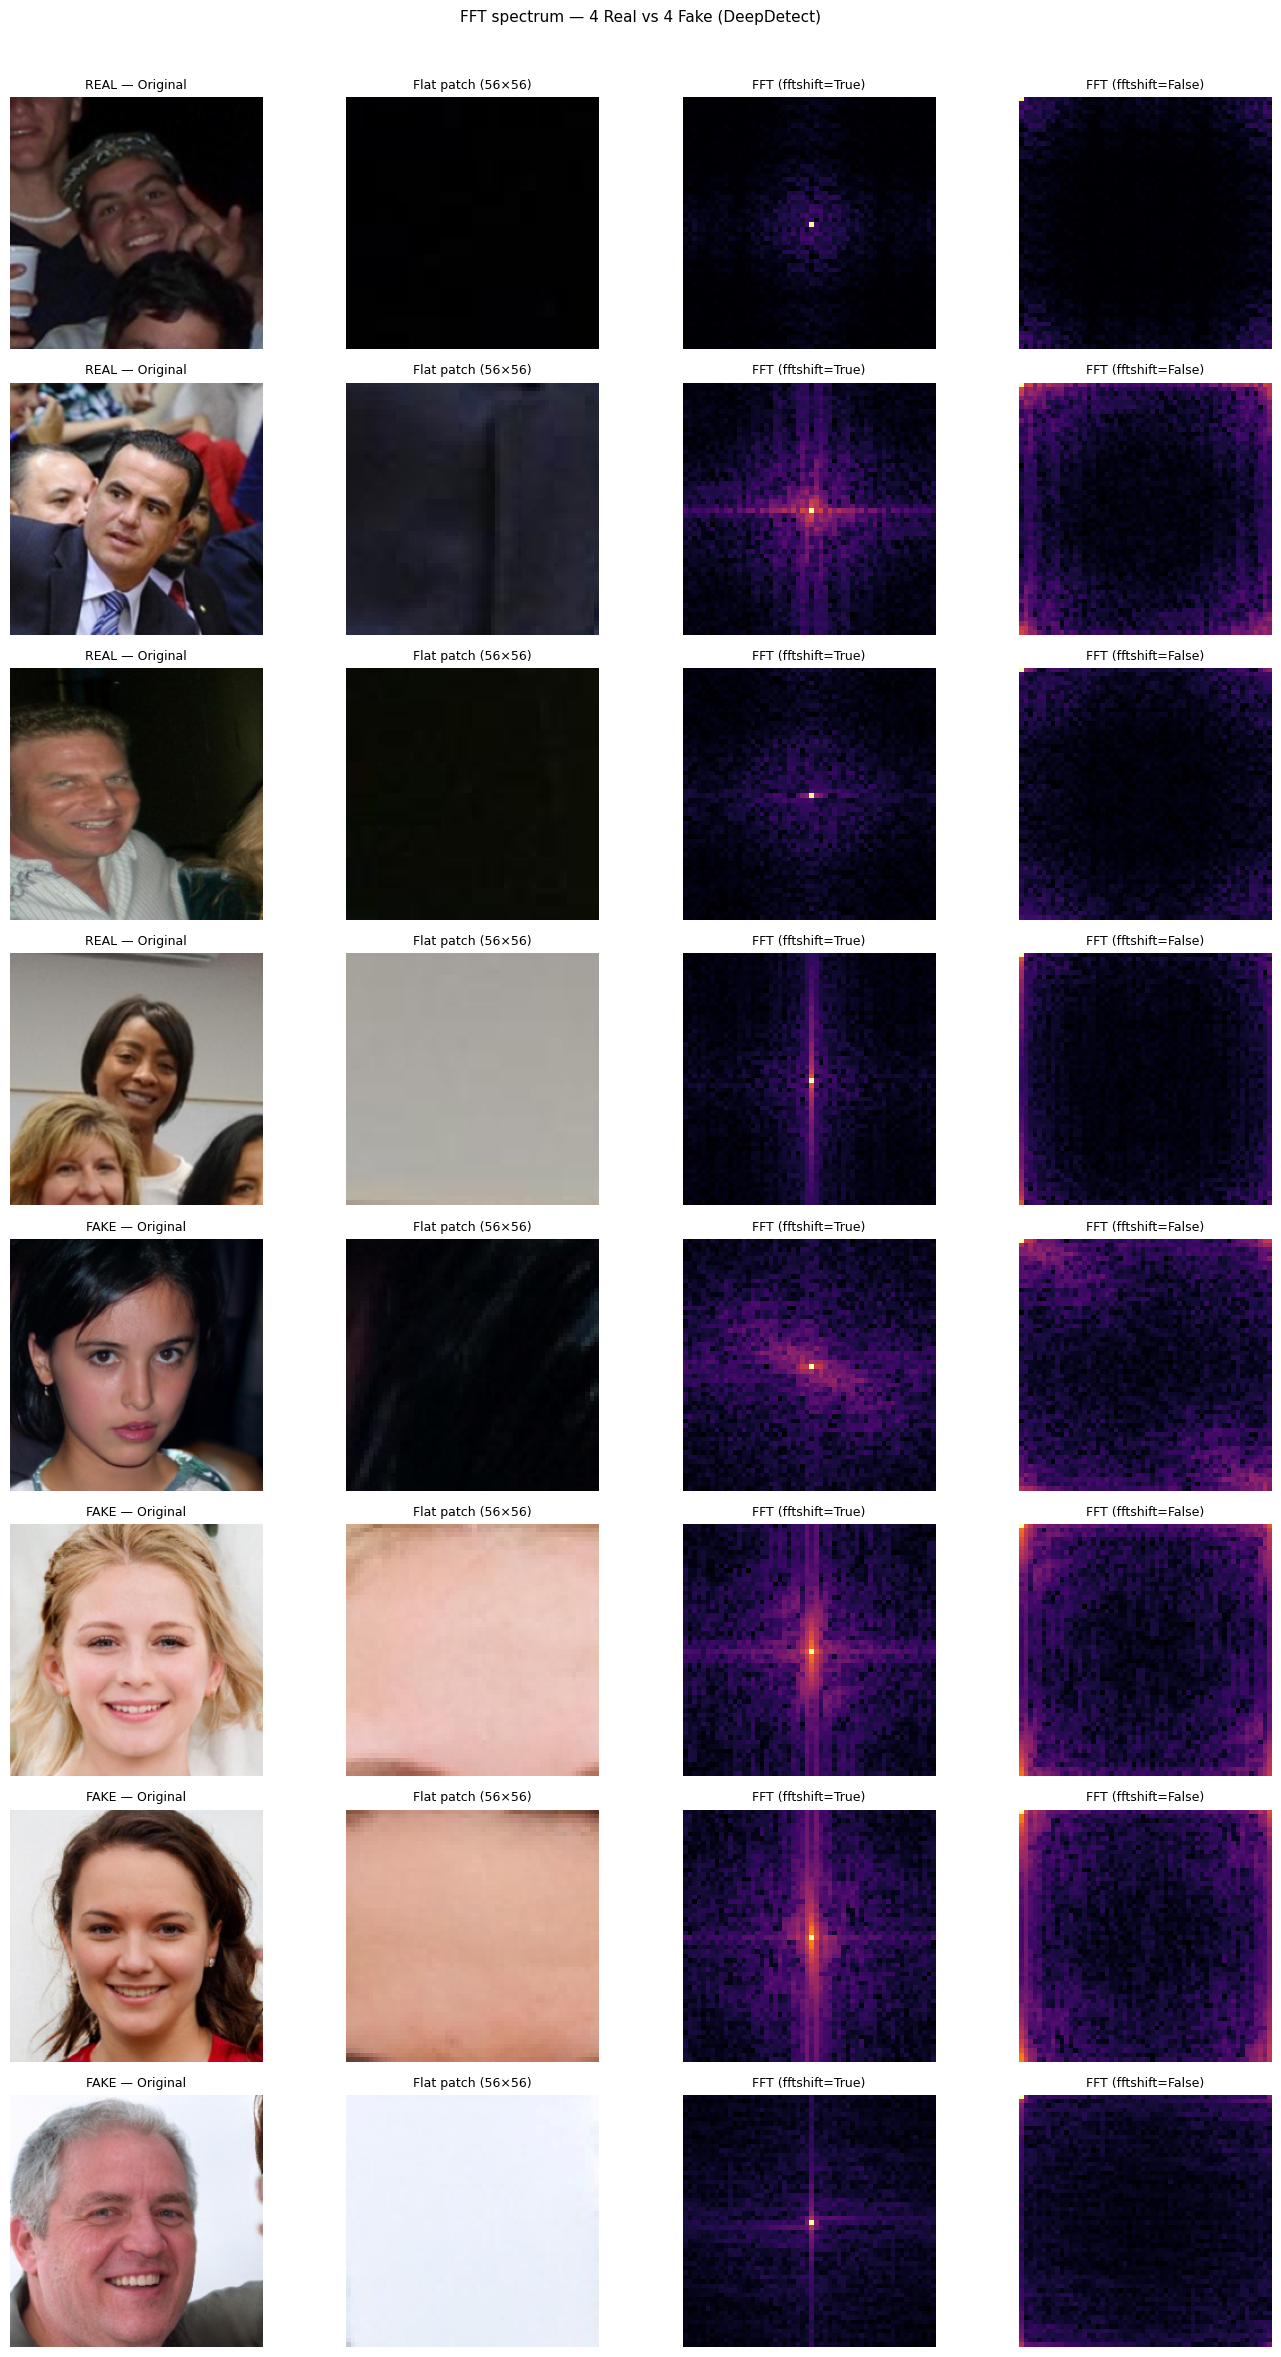

In [17]:
from utils.fft_utils import compute_log_fft
from utils.patch_select import select_flat_patch
import matplotlib.pyplot as plt

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def denorm(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (t * std + mean).clamp(0, 1)

N = 4  # number of real and fake examples each

real_imgs, fake_imgs = [], []
for imgs, lbls in test_loader:
    for img, lbl in zip(imgs, lbls):
        if lbl.item() == 0 and len(real_imgs) < N:
            real_imgs.append(img)
        if lbl.item() == 1 and len(fake_imgs) < N:
            fake_imgs.append(img)
    if len(real_imgs) >= N and len(fake_imgs) >= N:
        break

fig, axes = plt.subplots(N * 2, 4, figsize=(14, N * 6))

for i, (img, label_str) in enumerate(
    [(img, "REAL") for img in real_imgs] + [(img, "FAKE") for img in fake_imgs]
):
    row      = i
    img_np   = denorm(img).permute(1,2,0).numpy()
    patch    = select_flat_patch(img, patch_size=56)
    patch_np = denorm(patch).permute(1,2,0).numpy()
    gray     = patch.mean(0).numpy()
    spec_shift   = compute_log_fft(gray, fftshift=True)
    spec_noshift = compute_log_fft(gray, fftshift=False)

    axes[row][0].imshow(img_np)
    axes[row][0].set_title(f"{label_str} — Original", fontsize=9)
    axes[row][1].imshow(patch_np)
    axes[row][1].set_title("Flat patch (56×56)", fontsize=9)
    axes[row][2].imshow(spec_shift,   cmap="inferno")
    axes[row][2].set_title("FFT (fftshift=True)", fontsize=9)
    axes[row][3].imshow(spec_noshift, cmap="inferno")
    axes[row][3].set_title("FFT (fftshift=False)", fontsize=9)
    for ax in axes[row]:
        ax.axis("off")

plt.suptitle(f"FFT spectrum — {N} Real vs {N} Fake (DeepDetect)", fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Patches analysed:        512
Mean patch brightness:   0.387
Fraction dark (< 0.2):   38.9%
Mean patch variance:     0.16713


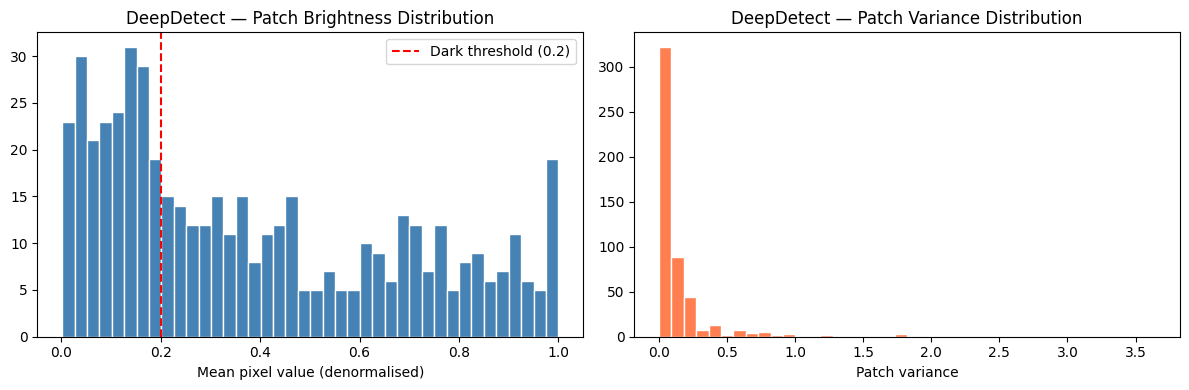

In [9]:
patch_means = []
patch_vars  = []
n_samples   = 500

for i, (imgs, lbls) in enumerate(test_loader):
    for img in imgs:
        patch = select_flat_patch(img, patch_size=56)
        # Denorm to get actual pixel values
        mean_val = (patch * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) 
                    + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)).mean().item()
        var_val  = patch.var().item()
        patch_means.append(mean_val)
        patch_vars.append(var_val)
    if len(patch_means) >= n_samples:
        break

patch_means = np.array(patch_means)
patch_vars  = np.array(patch_vars)

# What fraction of patches are very dark (mean < 0.2)?
dark_fraction = (patch_means < 0.2).mean()

print(f"Patches analysed:        {len(patch_means)}")
print(f"Mean patch brightness:   {patch_means.mean():.3f}")
print(f"Fraction dark (< 0.2):   {dark_fraction:.1%}")
print(f"Mean patch variance:     {patch_vars.mean():.5f}")

# Compare with CIFAKE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(patch_means, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0.2, color='red', linestyle='--', label='Dark threshold (0.2)')
axes[0].set_title("DeepDetect — Patch Brightness Distribution")
axes[0].set_xlabel("Mean pixel value (denormalised)")
axes[0].legend()

axes[1].hist(patch_vars, bins=40, color='coral', edgecolor='white')
axes[1].set_title("DeepDetect — Patch Variance Distribution")
axes[1].set_xlabel("Patch variance")

plt.tight_layout()
plt.show()

Train: 85,000  Val: 15,000  Test: 20,000
                                 DeepDetect       CIFAKE
Patches analysed                        512          512
Mean patch brightness                 0.387        0.479
Fraction dark (< 0.2)                 38.9%         1.0%
Mean patch variance                 0.16713      0.93789


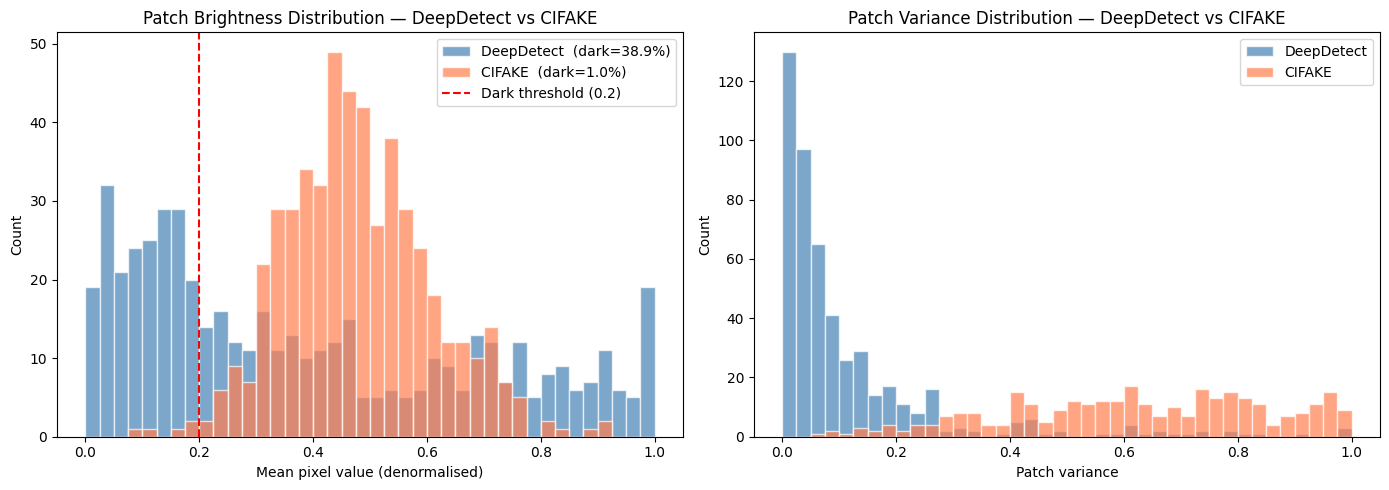

In [18]:
from data.cifake import get_cifake_loaders
from utils.patch_select import select_flat_patch

# ── CIFAKE sampling ──────────────────────────────────────────────
cfg_cf = Config()
cfg_cf.data.image_size  = 32
cfg_cf.data.batch_size  = 64
cfg_cf.data.num_workers = 4
cfg_cf.data.cifake_root = "../data/raw/cifake"

_, _, cifake_test_loader = get_cifake_loaders(cfg_cf)

cifake_means = []
cifake_vars  = []
n_samples    = 512

for imgs, lbls in cifake_test_loader:
    for img in imgs:
        patch = select_flat_patch(img, patch_size=32)  # whole image at 32x32
        mean_val = (patch * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
                    + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)).mean().item()
        var_val  = patch.var().item()
        cifake_means.append(mean_val)
        cifake_vars.append(var_val)
    if len(cifake_means) >= n_samples:
        break

cifake_means = np.array(cifake_means[:n_samples])
cifake_vars  = np.array(cifake_vars[:n_samples])

# ── Print stats ──────────────────────────────────────────────────
dd_dark     = (patch_means < 0.2).mean()
cifake_dark = (cifake_means < 0.2).mean()

print(f"{'':30} {'DeepDetect':>12} {'CIFAKE':>12}")
print(f"{'Patches analysed':<30} {len(patch_means):>12} {len(cifake_means):>12}")
print(f"{'Mean patch brightness':<30} {patch_means.mean():>12.3f} {cifake_means.mean():>12.3f}")
print(f"{'Fraction dark (< 0.2)':<30} {dd_dark:>12.1%} {cifake_dark:>12.1%}")
print(f"{'Mean patch variance':<30} {patch_vars.mean():>12.5f} {cifake_vars.mean():>12.5f}")

# ── Side by side plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.linspace(0, 1, 41)

axes[0].hist(patch_means,  bins=bins, alpha=0.7, color='steelblue',
             label=f'DeepDetect  (dark={dd_dark:.1%})', edgecolor='white')
axes[0].hist(cifake_means, bins=bins, alpha=0.7, color='coral',
             label=f'CIFAKE  (dark={cifake_dark:.1%})', edgecolor='white')
axes[0].axvline(0.2, color='red', linestyle='--', label='Dark threshold (0.2)')
axes[0].set_title("Patch Brightness Distribution — DeepDetect vs CIFAKE")
axes[0].set_xlabel("Mean pixel value (denormalised)")
axes[0].set_ylabel("Count")
axes[0].legend()

vbins = np.linspace(0, 1, 41)
axes[1].hist(patch_vars,  bins=vbins, alpha=0.7, color='steelblue',
             label='DeepDetect', edgecolor='white')
axes[1].hist(cifake_vars, bins=vbins, alpha=0.7, color='coral',
             label='CIFAKE', edgecolor='white')
axes[1].set_title("Patch Variance Distribution — DeepDetect vs CIFAKE")
axes[1].set_xlabel("Patch variance")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Train Frequency-Only Baseline

In [20]:
from experiments.baseline_freq_only import run_freq_only_baseline

freq_acc = run_freq_only_baseline(cfg, train_loader, val_loader, test_loader)



Experiment: dd_freq_only_baseline
Frequency-only baseline | Epochs: 30
Train: 76,848  Val: 13,561



Epoch   1/30 | train_loss=0.6900 | val_acc=54.6%
  -> Saved best val_acc=54.6%


Epoch   2/30 | train_loss=0.6865 | val_acc=55.4%
  -> Saved best val_acc=55.4%


Epoch   3/30 | train_loss=0.6844 | val_acc=53.7%


Epoch   4/30 | train_loss=0.6840 | val_acc=54.7%


...

Epoch  26/30 | train_loss=0.6699 | val_acc=57.6%
  -> Saved best val_acc=57.6%


Epoch  27/30 | train_loss=0.6691 | val_acc=57.5%


Epoch  28/30 | train_loss=0.6682 | val_acc=57.5%


Epoch  29/30 | train_loss=0.6691 | val_acc=57.6%


Epoch  30/30 | train_loss=0.6681 | val_acc=57.5%

Frequency-only final results:
  Accuracy: 58.6%
  AUC-ROC:  0.613
  F1:       0.417


Result: FAIL — frequency branch is below 60%.
Do not proceed to fusion. Fix the FFT representation first.
Results saved → ./results/results.csv  (dd_freq_only_baseline, acc=0.5861)

Results saved to ./results/results.csv


On CIFAKE, where images are 32×32 pixels, the patch size equals the full image. The entire image is fed to the frequency branch rather than a selected sub-region. This is because at 32×32 resolution there is no meaningful sub-region to select. Any 56×56 patch would exceed the image dimensions, so the full image is used as the patch. This guarantees a clean, content-rich input regardless of image content. On DeepDetect at 224×224, a genuine 56×56 sub-patch must be selected from the image, and the variance-based selector consistently finds uninformative dark background corners. Analysis of 512 patches reveals that 38.9% of DeepDetect patches are dark background corners (mean brightness < 0.2) compared to just 1.0% on CIFAKE. The variance-based patch selector fails on face-dominated images because the lowest-variance region is almost always a dark background corner rather than smooth skin. This creates an asymmetry where real images produce near-black, near-empty patches with almost no FFT signal, while fake images land on smooth skin regions that show visible periodic artifacts from GAN and diffusion model upsampling. The frequency branch therefore captures content differences between patches rather than genuine generation artifacts, making its representation unreliable on this dataset.